In [ ]:
# ---------- Task 1.1 : Load the Dataset ----------

import pandas as pd

column_headers = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]

banknote_data = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=column_headers
)

In [ ]:
# ---------- Task 1.2 : First Five Samples ----------

print("First Five Samples:")
print(banknote_data.head())

First Five Samples:
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [ ]:
# ---------- Task 1.3 : Dataset Dimensions ----------

print("Dataset Shape:")
print(banknote_data.shape)

Dataset Shape:
(1372, 5)


In [ ]:
# ---------- Task 1.4 : Missing Values ----------

print("Missing Values:")
print(banknote_data.isna().sum())

Missing Values:
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [ ]:
# ---------- Task 1.5 : Descriptive Statistics ----------

print("Descriptive Statistics:")
print(banknote_data.describe())

Descriptive Statistics:
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


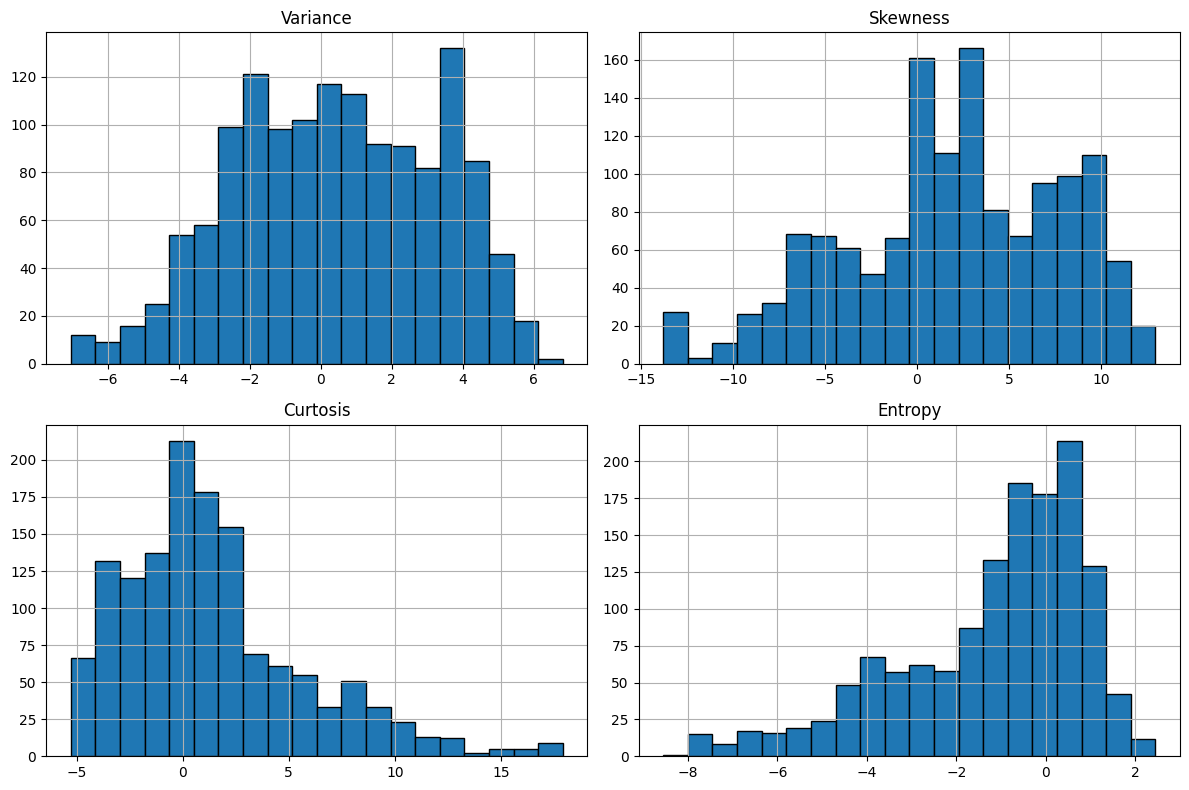

In [ ]:
# ---------- Task 2.1 : Feature Histograms ----------

import matplotlib.pyplot as plt

feature_matrix = banknote_data.drop(columns="Class")

feature_matrix.hist(
    figsize=(12, 8),
    bins=20,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

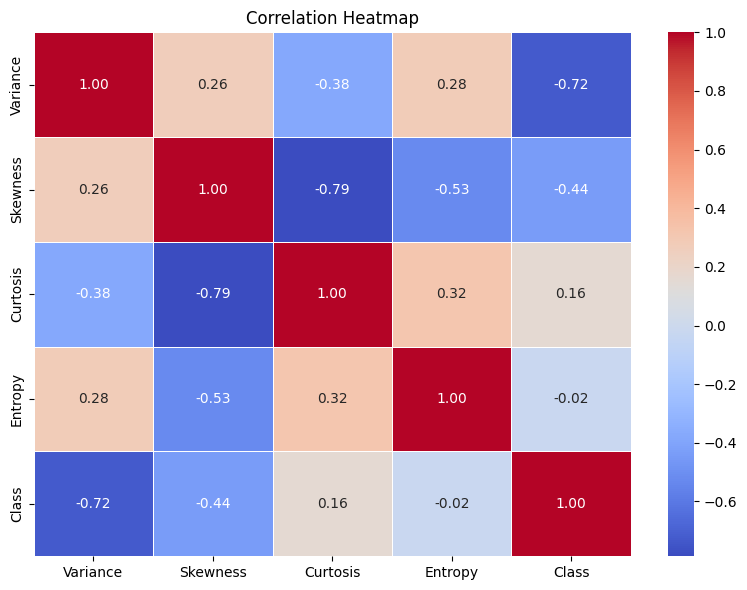

In [ ]:
# ---------- Task 2.2 : Correlation Heatmap ----------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

feature_correlation = banknote_data.corr(numeric_only=True)

sns.heatmap(
    feature_correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

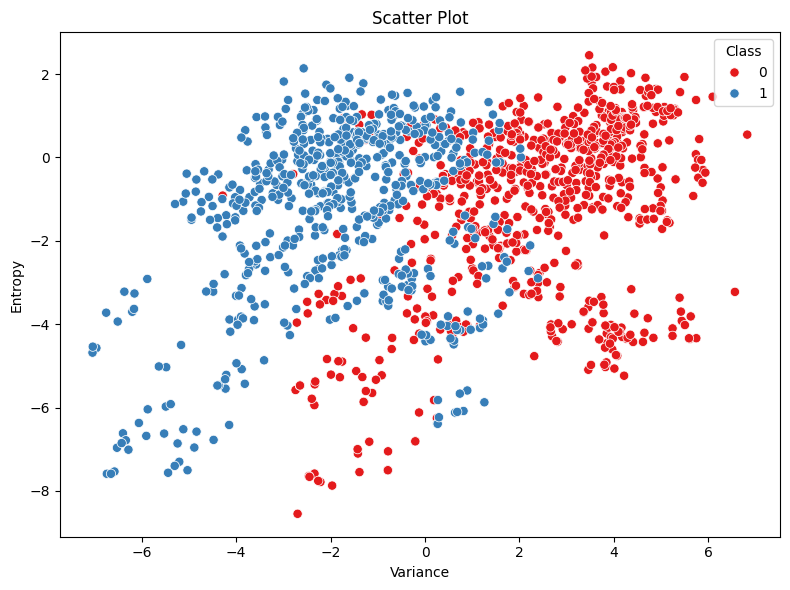

In [ ]:
# ---------- Task 2.3 : Scatter Plot ----------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=banknote_data,
    x="Variance",
    y="Entropy",
    hue="Class",
    palette="Set1",
    s=45
)

plt.title("Scatter Plot")
plt.tight_layout()
plt.show()

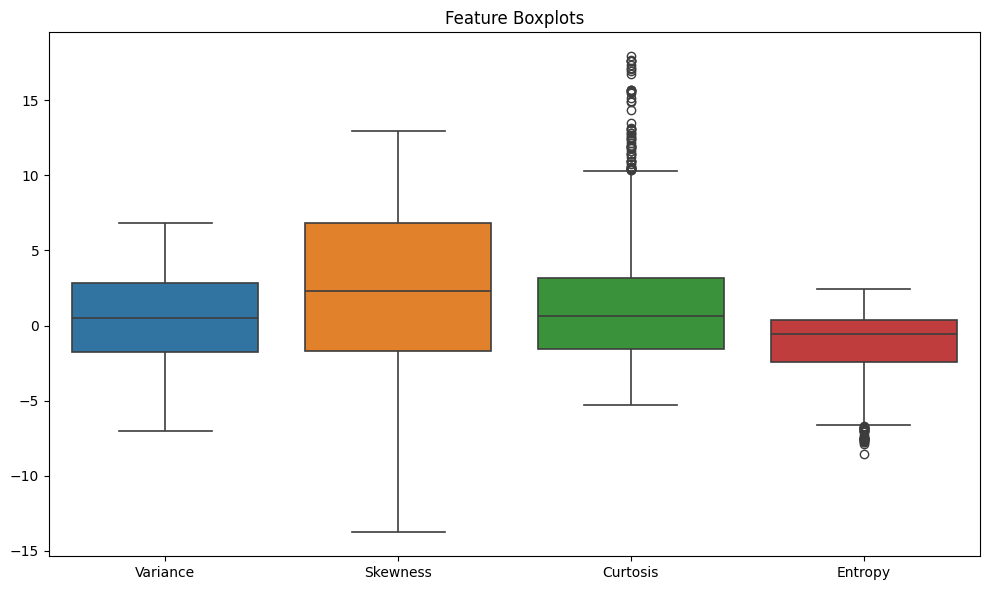

In [ ]:
# ---------- Task 2.4 : Boxplots ----------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=banknote_data.drop(columns="Class"),
    linewidth=1.2
)

plt.title("Feature Boxplots")
plt.tight_layout()
plt.show()

In [ ]:
# ---------- Task 3.1 : Normalize Numerical Features ----------

from sklearn.preprocessing import MinMaxScaler

feature_matrix = banknote_data.drop(columns="Class")
class_labels = banknote_data["Class"]

feature_scaler = MinMaxScaler()

normalized_features = feature_scaler.fit_transform(feature_matrix)

normalized_features = pd.DataFrame(
    normalized_features,
    columns=feature_matrix.columns
)

In [ ]:
# ---------- Task 3.2 : Normalized Features ----------

print("First Five Normalized Samples:")
print(normalized_features.head())

First Five Normalized Samples:
   Variance  Skewness  Curtosis   Entropy
0  0.769004  0.839643  0.106783  0.736628
1  0.835659  0.820982  0.121804  0.644326
2  0.786629  0.416648  0.310608  0.786951
3  0.757105  0.871699  0.054921  0.450440
4  0.531578  0.348662  0.424662  0.687362


In [ ]:
# ---------- Task 3.3 : Train-Test Split ----------

from sklearn.model_selection import train_test_split

train_data, test_data, train_target, test_target = train_test_split(
    normalized_features,
    class_labels,
    test_size=0.20,
    random_state=24,
    shuffle=True
)

print("Training Feature Shape:")
print(train_data.shape)

print("\nTesting Feature Shape:")
print(test_data.shape)

print("\nTraining Label Shape:")
print(train_target.shape)

print("\nTesting Label Shape:")
print(test_target.shape)

Training Feature Shape:
(1097, 4)

Testing Feature Shape:
(275, 4)

Training Label Shape:
(1097,)

Testing Label Shape:
(275,)


In [ ]:
# ---------- Task 4.1 : Initialize Model Parameters ----------

import numpy as np

perceptron_model = {
    "weights": np.zeros(train_data.shape[1]),
    "bias": 0.0,
    "learning_rate": 0.01
}

In [ ]:
# ---------- Task 4.2 : Step Activation Function ----------

def step_activation(input_value):

    return int(input_value >= 0)

In [ ]:
# ---------- Task 4.3 : Forward Propagation ----------

def forward_pass(sample_values):

    weighted_sum = (
        np.dot(sample_values,
               perceptron_model["weights"])
        + perceptron_model["bias"]
    )

    return step_activation(weighted_sum)

In [ ]:
# ---------- Task 4.4 : Parameter Update Rule ----------

def update_parameters(sample_values, expected_output):

    predicted_output = forward_pass(sample_values)

    prediction_error = expected_output - predicted_output

    perceptron_model["weights"] += (
        perceptron_model["learning_rate"]
        * prediction_error
        * sample_values
    )

    perceptron_model["bias"] += (
        perceptron_model["learning_rate"]
        * prediction_error
    )

    return prediction_error

In [ ]:
# ---------- Task 5.1 : Model Training ----------

import pandas as pd
import numpy as np

epoch_limit = 100

training_history = []

weight_history = []

for current_epoch in range(1, epoch_limit + 1):

    shuffled_index = np.random.permutation(len(train_data))

    shuffled_features = train_data.to_numpy()[shuffled_index]
    shuffled_labels = train_target.to_numpy()[shuffled_index]

    misclassified_count = 0

    for sample_values, expected_output in zip(
        shuffled_features,
        shuffled_labels
    ):

        prediction_error = update_parameters(
            sample_values,
            expected_output
        )

        if prediction_error != 0:
            misclassified_count += 1

    current_weights = perceptron_model["weights"].copy()

    weight_history.append(current_weights)

    training_history.append({
        "Epoch": current_epoch,
        "Misclassified Samples": misclassified_count,
        "Weight 1": round(current_weights[0], 4),
        "Weight 2": round(current_weights[1], 4),
        "Weight 3": round(current_weights[2], 4),
        "Weight 4": round(current_weights[3], 4),
        "Bias": round(perceptron_model["bias"], 4)
    })

    if misclassified_count == 0:
        break

training_summary = pd.DataFrame(training_history)

print(training_summary)

    Epoch  Misclassified Samples  Weight 1  Weight 2  Weight 3  Weight 4  Bias
0       1                    175   -0.0745   -0.0541   -0.0577    0.0151  0.07
1       2                     65   -0.0963   -0.0668   -0.0770    0.0117  0.08
2       3                     57   -0.0920   -0.0673   -0.0867    0.0112  0.11
3       4                     61   -0.0968   -0.0879   -0.0909    0.0122  0.12
4       5                     38   -0.1010   -0.0987   -0.0981    0.0153  0.12
..    ...                    ...       ...       ...       ...       ...   ...
95     96                     27   -0.2288   -0.2334   -0.2502    0.0078  0.31
96     97                     38   -0.2310   -0.2368   -0.2515    0.0132  0.31
97     98                     32   -0.2325   -0.2378   -0.2556    0.0078  0.31
98     99                     13   -0.2252   -0.2313   -0.2564    0.0095  0.32
99    100                     21   -0.2301   -0.2384   -0.2603    0.0007  0.31

[100 rows x 7 columns]


In [ ]:
# ---------- Task 5.2 : Final Model Parameters ----------

print("Final Weights:")
print(np.round(perceptron_model["weights"], 4))

print("\nFinal Bias:")
print(round(perceptron_model["bias"], 4))

Final Weights:
[-0.2301 -0.2384 -0.2603  0.0007]

Final Bias:
0.31


In [ ]:
# ---------- Task 6.1 : Generate Predictions ----------

predicted_labels = []

for sample_values in test_data.to_numpy():

    predicted_labels.append(
        forward_pass(sample_values)
    )

predicted_labels = np.array(predicted_labels)

In [ ]:
# ---------- Task 6.2 : Performance Metrics ----------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

model_accuracy = accuracy_score(
    test_target,
    predicted_labels
)

model_precision = precision_score(
    test_target,
    predicted_labels
)

model_recall = recall_score(
    test_target,
    predicted_labels
)

model_f1 = f1_score(
    test_target,
    predicted_labels
)

print(f"Accuracy : {model_accuracy:.4f}")
print(f"Precision: {model_precision:.4f}")
print(f"Recall   : {model_recall:.4f}")
print(f"F1-Score : {model_f1:.4f}")

Accuracy : 0.9818
Precision: 1.0000
Recall   : 0.9603
F1-Score : 0.9798


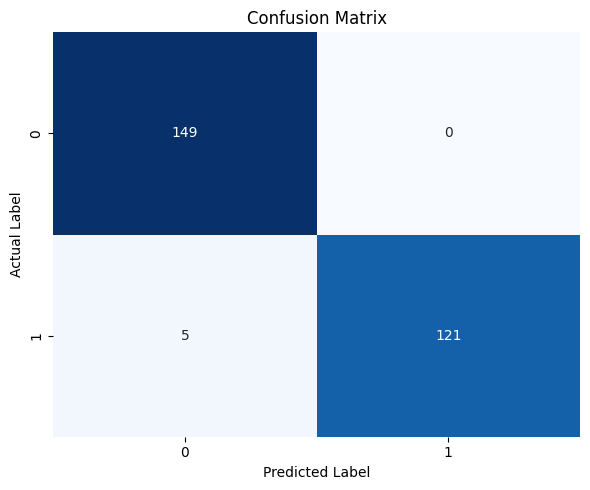

In [ ]:
# ---------- Task 6.3 : Confusion Matrix ----------

import matplotlib.pyplot as plt
import seaborn as sns

confusion_result = confusion_matrix(
    test_target,
    predicted_labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_result,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

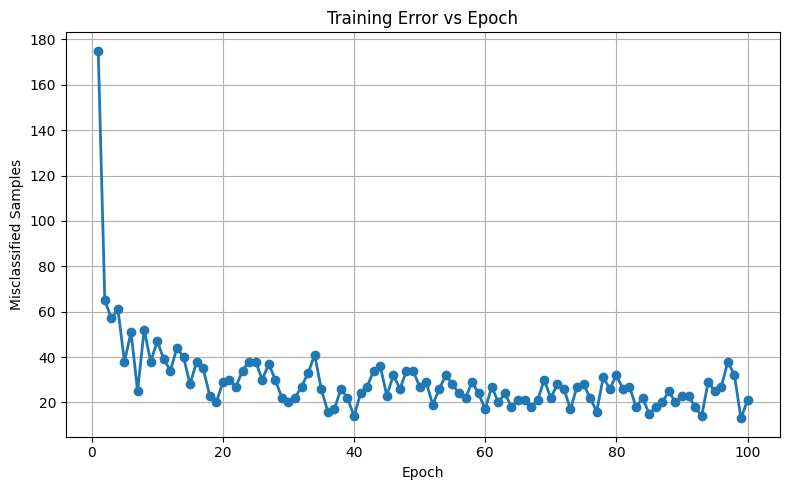

In [ ]:
# ---------- Task 7.1 : Training Error vs Epoch ----------

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    training_summary["Epoch"],
    training_summary["Misclassified Samples"],
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")

plt.grid(True)

plt.tight_layout()
plt.show()

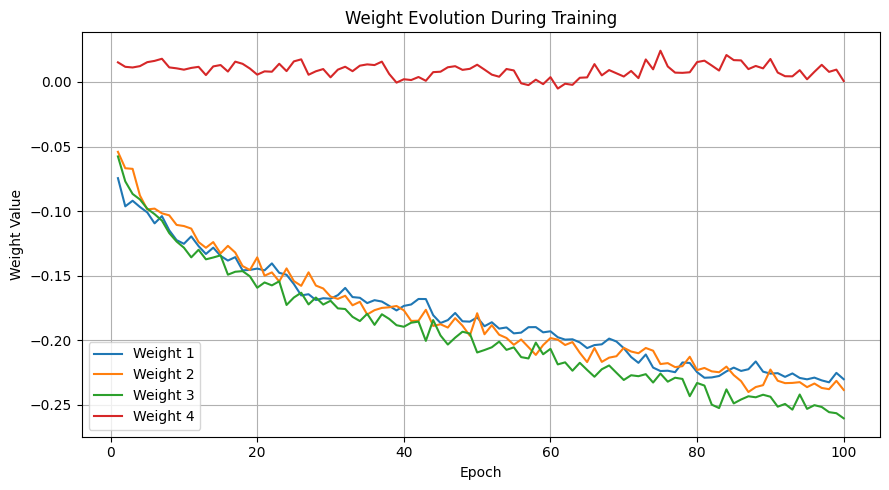

In [ ]:
# ---------- Task 7.2 : Weight Evolution ----------

import numpy as np
import matplotlib.pyplot as plt

weight_history_array = np.array(weight_history)

plt.figure(figsize=(9, 5))

for weight_index in range(weight_history_array.shape[1]):
    plt.plot(
        training_summary["Epoch"],
        weight_history_array[:, weight_index],
        label=f"Weight {weight_index + 1}"
    )

plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution During Training")
plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

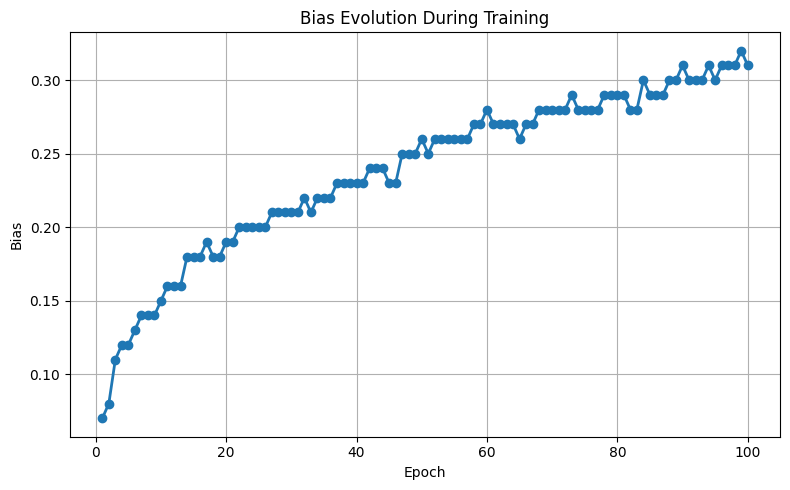

In [ ]:
# ---------- Bias Evolution Plot ----------

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    training_summary["Epoch"],
    training_summary["Bias"],
    marker="o",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.title("Bias Evolution During Training")

plt.grid(True)

plt.tight_layout()
plt.show()

   Learning Rate  Epochs  Accuracy
0          0.001     100    0.9964
1          0.010     100    0.9964
2          0.100     100    0.9891


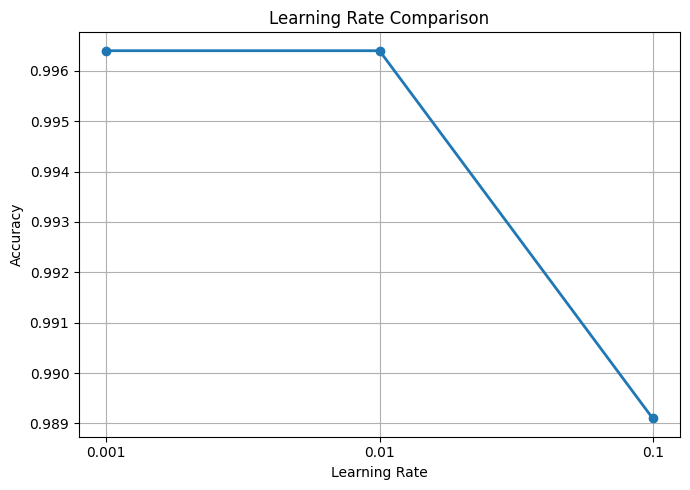

In [ ]:
# ---------- Learning Rate Comparison ----------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

learning_rates = [0.001, 0.01, 0.1]

comparison = []

for lr in learning_rates:

    weights = np.zeros(train_data.shape[1])
    bias = 0.0

    for epoch in range(100):

        shuffled = np.random.permutation(len(train_data))

        x_train = train_data.to_numpy()[shuffled]
        y_train = train_target.to_numpy()[shuffled]

        mistakes = 0

        for sample, label in zip(x_train, y_train):

            output = int(np.dot(sample, weights) + bias >= 0)

            error = label - output

            if error != 0:
                mistakes += 1

                weights += lr * error * sample
                bias += lr * error

        if mistakes == 0:
            break

    predictions = []

    for sample in test_data.to_numpy():
        predictions.append(
            int(np.dot(sample, weights) + bias >= 0)
        )

    accuracy = accuracy_score(
        test_target,
        predictions
    )

    comparison.append({
        "Learning Rate": lr,
        "Epochs": epoch + 1,
        "Accuracy": round(accuracy,4)
    })

comparison_table = pd.DataFrame(comparison)

print(comparison_table)

plt.figure(figsize=(7,5))

plt.plot(
    comparison_table["Learning Rate"].astype(str),
    comparison_table["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate Comparison")

plt.grid(True)

plt.tight_layout()
plt.show()